# MCMC with 5 free params, with added likelihood from the kband taken from the SED (in this case approximated by a Planck curve)

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import tensorflow as tf
import keras
import json
import pandas as pd
import corner
import emcee
import PyAstronomy.pyasl as pyasl
from astropy.io import fits
import warnings
import tqdm
%matplotlib widget 
# Jupyter only — replace with plt.ion() for script use

In [2]:
# Load BLOeM spectrum
BLOeM_fits_path = "BLOeM_4-074_Coadded.fits"
with fits.open(BLOeM_fits_path) as hdul:
    data = hdul[1].data

# Extract wavelength and flux from BLOeM
bloem_wl = data["WAVELENGTH"]   # Angstrom
bloem_flux = data["SCI_NORM"]   # Normalised flux

# --- Wavelength grid ---
df = pd.read_csv('wavelengths.csv')
master_wl_array = np.asarray(df['master wl Halpha_HeII6527 combined model 19002'])
order = np.argsort(master_wl_array)              # indices to sort wavelength array
master_wl_ordered = master_wl_array[order]
master_wl_unique, unique_idx = np.unique(master_wl_ordered, return_index=True)  # deduplicated grid
wl_min, wl_max = master_wl_unique.min(), master_wl_unique.max()
UNIFORM_STEP = 0.2                               # BLOeM resolution scale (~0.2 Å)
wl_uniform = np.arange(wl_min, wl_max, UNIFORM_STEP)

# --- Ks filter transmission (cached to avoid repeated disk reads) ---
band = 'SPHERE_Ks'
filterfile = 'SPHERE_IRDIS_B_Ks.dat'
filterdir = "filter_transmissions/"
_KS_WAVE, _KS_TRANS = np.genfromtxt(filterdir + filterfile, comments='#').T
_KS_WAVE *= 10  # nm → Å
zpfile = filterdir + 'zero_points.dat'
zp_values = np.genfromtxt(zpfile, comments='#', dtype=str)
zp_system = 'vega'  # Choose zero point system: 'vega', 'AB', or 'ST'
zpflux = ''
for afilter in zp_values:
    if afilter[0] == band:
        if zp_system == 'vega':
            zpflux = float(afilter[1])
        elif zp_system == 'AB':
            zpflux = float(afilter[2])
        elif zp_system == 'ST':
            zpflux = float(afilter[3])

# --- Parameter names (order must match theta vector throughout) ---
PARAM_NAMES = ['teff', 'logg', 'radius', 'logmdot', 'yhe']

#import Anja's model for inference
model = keras.saving.load_model('NN_model.keras')

# Load the normalization values
with open('normalisation.json') as f:
    norm = json.load(f)

/opt/miniconda3/envs/nn_env/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
def planck_wavelength(wave_angstrom, temp):
    ''' Calculate the Planck function as function of temperature and wavelength (in Angstrom. Output is then also in Angstrom).'''
    angstrom_to_cm = 1e-8
    wave = wave_angstrom * angstrom_to_cm
    # All units in cgs
    hh = 6.6260755e-27 #Planck constant;
    cc = 2.99792458e10 #speed of light in a vacuum;
    kk = 1.380658e-16 #Boltzmann constant;

    prefactor = 2.0 * hh * cc**2 / (wave**5)
    exponent = (hh * cc / kk) / (wave * temp)
    Blambda = prefactor * (1.0 / (np.exp(exponent)-1))
    Blambda = Blambda * angstrom_to_cm #Blambda from per cm to per angstrom
    return Blambda

def flux_to_magnitude(obsflux):
    ''' Calculate magnitude from observed flux and zeropoint flux'''
    magnitude = -2.5 * np.log10(obsflux / zpflux)
    return magnitude

def compute_obs_flux(teff, radius, Tfrac=0.9, d=10*3.08567758e18/6.96e10):
    ''' Calculate the observed flux in the K-band based on the given parameters.
    teff: effective temperature (K)
    radius: stellar radius (solar radii)
    Tfrac: fraction of teff to use for the blackbody calculation (default 0.9 to account for line formation in cooler layers)
    d: distance to the star (default 10 pc in cm, converted to solar radii)
    '''
    tBB = teff * Tfrac
    F_lambda = np.pi * planck_wavelength(_KS_WAVE, tBB)
    filtered_flux = np.trapz(_KS_TRANS * F_lambda, _KS_WAVE) / np.trapz(_KS_TRANS, _KS_WAVE)
    return (radius / d)**2 * filtered_flux

def normalize(col_name, unnormalized_val):
    mn = norm[f'{col_name}_min']
    mx = norm[f'{col_name}_max']
    return (unnormalized_val - mn) / (mx - mn)

def normalize_theta(theta):
    return np.array([normalize(name, val) for name, val in zip(PARAM_NAMES, theta)])

def add_noise_to_spectrum(prediction, spectral_snr):
    '''add Gaussian noise to the prediction and plot again'''
    spectral_sigma = 1/spectral_snr
    noisy_flux = prediction + np.random.normal(0.0, spectral_sigma, size=prediction.shape)
    return noisy_flux

def simulate_model_spectrum(theta, model=model, vsini=None, epsilon=None, output_wl=None):
    ''' Simulate the model spectrum for given parameters, with optional rotational broadening and interpolation to an output wavelength grid.
    theta: array of parameters [teff, logg, radius, logmdot, yhe]
    model: keras model to predict the spectrum
    vsini: projected rotational velocity (km/s) for rotational broadening (optional)
    epsilon: limb darkening coefficient for rotational broadening (optional)
    output_wl: wavelength grid to interpolate the final spectrum onto (optional; if None, returns on wl_uniform grid)
    '''
    norm_params = normalize_theta(theta) # normalize the input parameters to the [0,1] range expected by the model
    flux_master = model(norm_params[None, :], training=False).numpy().ravel() 
    flux_master_ordered = flux_master[order] # reorder + deduplicate
    flux_unique = flux_master_ordered[unique_idx] # flux_master is now on the master_wl_unique grid
    flux_out = np.interp(wl_uniform,master_wl_unique,flux_unique) # interpolate master → uniform grid
    if vsini is not None:
        flux_out = pyasl.rotBroad(wl_uniform,flux_out,epsilon=epsilon,vsini=vsini) # rotational broadening
    if output_wl is not None:
        flux_out=np.interp(output_wl,wl_uniform,flux_out) # interpolate master → output grid
    return flux_out

def simulate_kband_magnitude(theta):
    ''' Simulate the K-band magnitude for given parameters using a simple model based on the Planck function and filter transmission.'''
    teff, logg, radius, logmdot, yhe = theta
    # Calculate the K-band magnitude based on the parameters using a simple model
    model_flux = compute_obs_flux(teff, radius) # Calculate the observed flux in the K-band based on the given parameters
    kband_mag = flux_to_magnitude(model_flux) # Convert the observed flux to a K-band magnitude
    return kband_mag

def log_prior(theta):
    """ Define the log-prior for the parameters. Returns 0 (log(1)) if parameters are within the specified bounds, and -inf (log(0)) otherwise.
    theta: parameters [teff, logg, radius, logmdot, yhe]
    """
    teff, logg, radius, logmdot, yhe = theta
    if not (29000 <= teff <= 52000 and 3.4 <= logg <= 4.3 and 6 <= radius <= 21 and -7.5 <= logmdot <= -5.2 and 0.08 <= yhe <= 0.15):
        return -np.inf
    return 0.0

def make_log_posterior_with_kband(observed_wavelength,observed_flux,observed_kband,spectral_snr,kband_snr=20,vsini=None,epsilon=None,model=model):
    ''' Create a log-posterior function that combines the likelihood of the observed spectrum and the observed K-band magnitude, given the model predictions and uncertainties.
    model: keras model to predict the spectrum
    observed_wavelength: wavelength grid of the observed spectrum
    observed_flux: normalized observed spectrum
    observed_kband: observed K-band magnitude
    spectral_snr: signal-to-noise ratio of the observed spectrum (used to calculate the uncertainty for the spectral likelihood)
    kband_snr: signal-to-noise ratio of the K-band magnitude (used to calculate the uncertainty for the K-band likelihood)
    vsini: projected rotational velocity for rotational broadening (optional)
    epsilon: limb darkening coefficient for rotational broadening (optional)
    '''
    spectral_sigma = 1.0 / spectral_snr # Use the spectral SNR to calculate the uncertainty for the spectral likelihood
    kband_sigma = 1.0 / kband_snr # Use the K-band SNR to calculate the uncertainty

    def log_likelihood_kband(theta):
        sim_kband_mag = simulate_kband_magnitude(theta) # Simulate the K-band magnitude for the given parameters using the model
        residual_kband = observed_kband - sim_kband_mag # Calculate the residual between the observed and simulated K-band magnitudes
        ll_kband = -0.5 * (residual_kband / kband_sigma) ** 2 # Calculate the log-likelihood for the K-band magnitude assuming Gaussian errors
        return ll_kband if np.isfinite(ll_kband) else -np.inf # Return -inf if the log-likelihood is not finite (e.g., due to numerical issues)

    def log_likelihood_lines(theta):
        sim_flux = simulate_model_spectrum(theta, model=model, vsini=vsini, epsilon=epsilon, output_wl=observed_wavelength) # Simulate the model spectrum with noise and optional rotational broadening
        valid = ~np.isnan(sim_flux) # Only consider points where interpolation was valid (within the model's wavelength range)
        if not np.any(valid): # If no valid points, return -inf to indicate zero likelihood
            return -np.inf

        residual_lines = observed_flux[valid] - sim_flux[valid] # Calculate the residual between the observed and simulated spectra at the valid points
        ll_lines = -0.5 * np.sum((residual_lines / spectral_sigma) ** 2) # Calculate the log-likelihood for the spectral lines assuming Gaussian errors

        return ll_lines if np.isfinite(ll_lines) else -np.inf # Return -inf if the log-likelihood is not finite (e.g., due to numerical issues)

    def log_posterior_with_kband(theta):
        lp = log_prior(theta) # Calculate the log-prior for the given parameters
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood_lines(theta) + log_likelihood_kband(theta) # Combine the log-prior and log-likelihoods to get the log-posterior

    return log_posterior_with_kband

def run_mcmc_with_kband(observed_flux,observed_wavelength,observed_kband,spectral_snr,kband_snr,first_guess,
                        model=model,vsini=None,epsilon=None,ndim=5,nwalkers=24,nsteps=5000,thin=10,theta_true = None):
    """
    Parameters
    ----------
    observed_flux       : array  — normalised observed spectrum
    observed_wavelength : array  — wavelength grid of observed spectrum (Å), also the grid on which the model spectrum will be evaluated and compared to the observed spectrum
    observed_kband      : float  — observed K-band magnitude
    spectral_snr        : float  — signal-to-noise ratio of the spectrum
    kband_snr           : float  — signal-to-noise ratio of the K-band magnitude
    first_guess         : array  — initial parameter guess [teff, logg, radius, logmdot, yhe]
    model               : keras model — neural network emulator
    vsini               : float or None — projected rotational velocity (km/s)
    epsilon             : float or None — limb darkening coefficient for rotational broadening
    ndim                : int   — number of parameters (default 5)
    nwalkers            : int   — number of MCMC walkers (default 24)
    nsteps              : int   — number of MCMC steps (default 5000)
    thin                : int   — thinning factor for chain (default 10)
    theta_true          : array or None — ground truth parameters for validation plots

    Notes
    -----
    theta naming convention used throughout:
        first_guess  — user-supplied starting point
        theta_map    — MAP estimate from Nelder-Mead optimisation
        theta_50p    — median of posterior samples (returned as best estimate)
        theta_true   — known true values (only available for synthetic tests)
    """
    log_posterior = make_log_posterior_with_kband(model=model,observed_wavelength=observed_wavelength,observed_flux=observed_flux,observed_kband=observed_kband,
                                                    spectral_snr=spectral_snr,kband_snr=kband_snr,vsini=vsini,epsilon=epsilon) # Create log-posterior function with the observed data (spectrum and kband magnitude) and model

    res = minimize(lambda t: -log_posterior(t), first_guess, method="Nelder-Mead") # Find the MAP estimate starting from the initial guess
    theta_map = res.x # Extract the free parameters from the MAP estimate (the radius is calculated and not part of the MCMC sampling)
    scale = np.array([500, 0.05, 1, 0.1, 0.005]) # Scale for initializing walkers around the MAP estimate (adjusted to be smaller than the prior range to ensure good starting positions)
    pos = []
    while len(pos) < nwalkers:
        p = theta_map + scale * np.random.randn(ndim)
        if np.isfinite(log_posterior(p)):
            pos.append(p)
    pos = np.array(pos) # Initialize walkers around the MAP estimate
    
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior) # Set up the MCMC sampler
    print(f"Starting MCMC: {nwalkers} walkers × {nsteps} steps ({nwalkers * nsteps:,} total evaluations)")
    print(f"Initial position (MAP estimate): {dict(zip(PARAM_NAMES, np.round(theta_map, 3)))}")
    checkpoint_interval = max(1, nsteps // 10)
    for i, _ in enumerate(sampler.sample(pos, iterations=nsteps)):
        if (i + 1) % checkpoint_interval == 0:
            acceptance = sampler.acceptance_fraction.mean()
            print(f"  Step {i+1:>5}/{nsteps} ({100*(i+1)/nsteps:.0f}%)  —  mean acceptance: {acceptance:.3f}") # Print progress and acceptance rate every 10% of the total steps
    print("Sampling complete.")
    
    chain = sampler.chain # Extract the MCMC chain
    tau = sampler.get_autocorr_time(tol=0) # Estimate the autocorrelation time to determine how many steps to discard for burn-in
    max_tau = np.max(tau) # Use the maximum autocorrelation time across all parameters to be conservative in burn-in discarding
    if nsteps < 50 * max_tau:
        warnings.warn(
            f"Chain may not be converged: nsteps={nsteps} < 50 × max(tau)={50*max_tau:.0f}. "
            f"Consider running for at least {int(50*max_tau)} steps.",
            RuntimeWarning
        )
    discard = 3 * int(max_tau) # Discard 3 times the maximum autocorrelation time as burn-in
    flat_samples = sampler.get_chain(discard=discard, thin=thin, flat=True) # Flatten the chain after discarding burn-in and applying thinning
    print(f"\n--- Chain diagnostics ---")
    print(f"  Burn-in discarded : {discard} steps (3 × max τ)")
    print(f"  Thinning factor   : {thin}")
    print(f"  Samples remaining : {len(flat_samples)}")
    if len(flat_samples) < 1000:
        print("Warning: fewer than 1000 independent samples — consider running longer.")
    theta_50p = np.percentile(flat_samples, 50, axis=0) # Compute the median of the posterior samples for each parameter

    return {
        "observed_flux": observed_flux,
        "observed_wavelength": observed_wavelength,
        "observed_kband": observed_kband,
        "spectral_snr": spectral_snr,
        "first_guess": first_guess,
        "chain": chain,
        "flat_samples": flat_samples,
        "theta_map": theta_map,
        "theta_50p": theta_50p,
        "discard": discard,
        "theta_true": theta_true,
    }

def save_results(results, filename):
    np.savez(
        filename,
        observed_flux=results["observed_flux"],
        observed_wavelength=results["observed_wavelength"],
        observed_kband=results["observed_kband"],
        spectral_snr=results["spectral_snr"],
        first_guess=results["first_guess"],
        flat_samples=results["flat_samples"],
        theta_map=results["theta_map"],
        chain=results["chain"],
        theta_50p=results["theta_50p"],
        discard=results["discard"],
        theta_true=results["theta_true"] if "theta_true" in results else None,
    )

def load_results(filename):
    data = np.load(filename, allow_pickle=True)
    return {
        "observed_flux": data["observed_flux"],
        "observed_wavelength": data["observed_wavelength"],
        "observed_kband": data["observed_kband"],
        "spectral_snr": data["spectral_snr"],
        "first_guess": data["first_guess"],
        "flat_samples": data["flat_samples"],
        "theta_map": data["theta_map"],
        "chain": data["chain"],
        "discard": data["discard"],
        "theta_50p": data["theta_50p"],
        "theta_true": data["theta_true"] if "theta_true" in data else None,
    }

def print_posterior_summary(flat_samples, truths=None):
    print("Median and 1σ uncertainties:")
    for i, label in enumerate(PARAM_NAMES):
        p16, p50, p84 = np.percentile(flat_samples[:, i], [15.85, 50, 84.15]) # 16th, 50th, and 84th percentiles correspond to median and ±1σ for a Gaussian distribution
        print(f"{label} = {p50:.3f} -{p50-p16:.3f}/+{p84-p50:.3f}, true {label} = {truths[i]:.3f}" if truths is not None else f"{label} = {p50:.3f} -{p50-p16:.3f}/+{p84-p50:.3f}")

def plot_corner(flat_samples, truths=None):
    if truths is not None:
        corner.corner(flat_samples,labels=PARAM_NAMES, truths=truths)
    else:
        corner.corner(flat_samples,labels=PARAM_NAMES)
    plt.show()

def plot_chains(chain, ndim, discard, truths=None):
    fig, axes = plt.subplots(ndim, 1, figsize=(10, 10), sharex=True)
    for i in range(ndim):
        axes[i].plot(chain[:, :, i].T, alpha=0.3, color='black')
        axes[i].axvline(discard, color='blue', linestyle='--', label='Discarded steps')
        if truths is not None:
            axes[i].axhline(truths[i], color='red', linestyle='-', label='True value')
        axes[i].set_ylabel(PARAM_NAMES[i])
        axes[i].legend()
    axes[-1].set_xlabel("Step")
    plt.show()

def plot_posterior_predictive(results,observed_flux,observed_wavelength,spectral_snr,model=model,vsini=None, epsilon=None, show_draws=True, n_draw=100):
    flat_samples = results["flat_samples"]
    theta_50p = results["theta_50p"]

    plt.figure(figsize=(15, 6))
    sim_50p_flux = simulate_model_spectrum(theta_50p, model=model, vsini=vsini, epsilon=epsilon, output_wl=observed_wavelength) # Simulate the 50th percentile theta spectrum with noise and optional rotational broadening
    sim_50p_flux = add_noise_to_spectrum(sim_50p_flux, spectral_snr) # Add noise to the simulated spectrum based on the specified SNR
    plt.plot(observed_wavelength, observed_flux, color='black', label='Observed spectrum', lw=0.8)
    if show_draws:
        idx = np.random.choice(len(flat_samples), n_draw, replace=False) # Randomly select n_draw samples from the posterior without replacement
        draw_samples = flat_samples[idx] # Extract the selected samples for plotting
        for i, theta in enumerate(draw_samples):
            sample_flux = simulate_model_spectrum(theta, model=model, vsini=vsini, epsilon=epsilon, output_wl=observed_wavelength) # Simulate the spectrum for this sample with noise and optional rotational broadening
            sample_flux = add_noise_to_spectrum(sample_flux, spectral_snr) # Add noise to the simulated spectrum based on the specified SNR
            plt.plot(observed_wavelength,sample_flux,color='tab:blue',alpha=0.25,linewidth=1,label=f"Posterior Predictive {n_draw} samples" if i == 0 else None)
    plt.plot(observed_wavelength, sim_50p_flux, color='orange', alpha=0.8, lw=1, label='Median posterior predictive')
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    plt.legend()
    plt.show()

def get_credible_interval_mcmc(flat_samples, truth, param_index):
    """
    Compute the posterior percentile rank of the truth value for one parameter using unweighted MCMC samples.
    ----------
    flat_samples : array, shape (Nsamples, ndim)
        Posterior samples from emcee.
    truth : float
        True parameter value.
    param_index : int
        Which parameter column to use.
    -------
    float
        Fraction of posterior samples below the truth value.
    """
    samples_1d = flat_samples[:, param_index] # extract one parameter
    return np.mean(samples_1d < truth) # fraction of samples below truth

from scipy.stats import binom

def run_coverage_test(wl_array_output, spectral_snr, kband_snr, N_sims=20, nsteps=5000, nwalkers=24, thin=10, ndims=5, simulate=True, theta_true=None, model=model, vsini=None, epsilon=None):
    """
    Run a Bayesian coverage test (PP plot test) for all 5 parameters using repeated noisy simulations.
    ----------
    wl_array : array
        Model wavelength grid.
    snr : float
        Noise level used for simulations and inference.
    log_prior : function
        Prior function.
    N_sims : int
        Number of repeated simulations.
    nsteps, nwalkers, thin : int
        MCMC control parameters.
    simulate : bool
        If True, simulate new true parameters for each run. If False, use provided theta_true for all runs. theta_true : array-like, shape (5,) If simulate=False, the true parameter values to use for all simulations.
    theta_true : array-like, shape (N_sims, 5) or (5,)
        If simulate=False, the true parameter values to use for all simulations. If shape is (5,), the same true parameters will be used for all simulations. If shape is (N_sims, 5), each row will be used as the true parameters for one simulation.
    model : keras model
        Your neural network spectral emulator.
    -------
    credible_dict : dict
        Credible ranks for each parameter.
    """
    # Sample N true values for each parameter from the prior range
    if simulate:
        teff_true = np.random.uniform(29000, 52000, size=N_sims)
        logg_true = np.random.uniform(3.4, 4.3, size=N_sims)
        radius_true = np.random.uniform(6, 21, size=N_sims)
        logmdot_true = np.random.uniform(-7.5, -5.2, size=N_sims)
        yhe_true = np.random.uniform(0.08, 0.15, size=N_sims)
        theta_true = np.column_stack([teff_true, logg_true, radius_true, logmdot_true, yhe_true])
    else:
         theta_true = theta_true
    
    # Generate one random first guess per simulation
    guesses = np.zeros((N_sims, 5))
    guesses[:,0] = np.random.randint(29000, 52000, size=N_sims) # Teff within prior
    guesses[:,1] = np.random.uniform(3.4, 4.3, size=N_sims) # logg within prior
    guesses[:,2] = np.random.uniform(6, 21, size=N_sims) # radius within prior
    guesses[:,3] = np.random.uniform(-7.5, -5.2, size=N_sims) # logmdot within prior
    guesses[:,4] = np.random.uniform(0.08, 0.15, size=N_sims) # yhe within prior

    credible_dict = {name: [] for name in PARAM_NAMES} # Storage: one list per parameter
    flat_samples_all, chain_all, discard_all, results_all = [], [], [], [] # Storage for all flat samples, chains, discards, and results
    print(f"Running coverage test with N_sims = {N_sims}")

    for k in range(N_sims): # Loop over repeated simulations

        print(f"Simulation {k+1}/{N_sims}")

        observed_flux = simulate_model_spectrum(theta_true[k],model=model,vsini=vsini,epsilon=epsilon,output_wl=wl_array_output) # Simulate the observed spectrum for the true parameters on the output wavelength grid
        observed_flux = add_noise_to_spectrum(observed_flux, spectral_snr) # Add noise to the simulated spectrum based on the specified SNR
        observed_kband = simulate_kband_magnitude(theta_true[k]) + np.random.normal(0, 1/kband_snr) # Simulate the observed K-band magnitude for the true parameters and add noise based on the specified K-band SNR

        # Run inference
        results = run_mcmc_with_kband(
            observed_flux=observed_flux,
            observed_wavelength=wl_array_output,
            observed_kband=observed_kband,
            spectral_snr=spectral_snr,
            kband_snr=kband_snr,
            first_guess=guesses[k],
            model=model,
            vsini=vsini,
            epsilon=epsilon,
            ndim=ndims,
            nwalkers=nwalkers,
            nsteps=nsteps,
            thin=thin,
            theta_true = theta_true[k],
        )

        results_all.append(results)
        discard_all.append(results["discard"])
        chain_all.append(results["chain"])
        flat_samples_all.append(results["flat_samples"])

        for j, name in enumerate(PARAM_NAMES): # Compute credible ranks for each parameter

            u = get_credible_interval_mcmc(results["flat_samples"],truth=theta_true[k,j],param_index=j)
            credible_dict[name].append(u)

    return credible_dict, theta_true, flat_samples_all, guesses, discard_all, chain_all, results_all

def plot_coverage_all_params(credible_dict):
    """
    Plot one PP coverage curve for each parameter, including expected binomial scatter bands.
    """

    fig, ax = plt.subplots(figsize=(7, 7))
    x_values = np.linspace(0.0, 1.0, 1001)
    ax.plot([0, 1], [0, 1], "--", color="black") # Ideal diagonal

    # Number of simulations
    first_param = list(credible_dict.keys())[0]
    N = len(credible_dict[first_param])

    # Expected statistical scatter bands
    bands = [0.68, 0.95, 0.997]
    band_alpha = [0.3, 0.15, 0.1]
    
    for ci, alpha in zip(bands, band_alpha):
            edge = (1.0 - ci) / 2.0 # Two-tailed
            lower = binom.ppf(edge, N, x_values) / N # Lower bound of binomial confidence interval
            upper = binom.ppf(1 - edge, N, x_values) / N # Upper bound of binomial confidence interval
            lower[0] = 0 # Ensure the bands start at (0,0) and end at (1,1)
            upper[0] = 0
            ax.fill_between(x_values, lower, upper, alpha=alpha, color="grey") # Plot binomial confidence bands

    for name in PARAM_NAMES: # Plot each parameter curve
        credible_intervals = np.asarray(credible_dict[name]) # Extract credible intervals
        pp = np.array([np.mean(credible_intervals < xx)for xx in x_values]) # Empirical coverage
        ax.plot(x_values, pp, lw=2, label=name) # Plot curve

    ax.set_xlabel("Credible interval")
    ax.set_ylabel("Fraction of events in credible interval")
    ax.set_title(f"Coverage test (PP plot) with {N} simulations")
    ax.legend()
    plt.show()

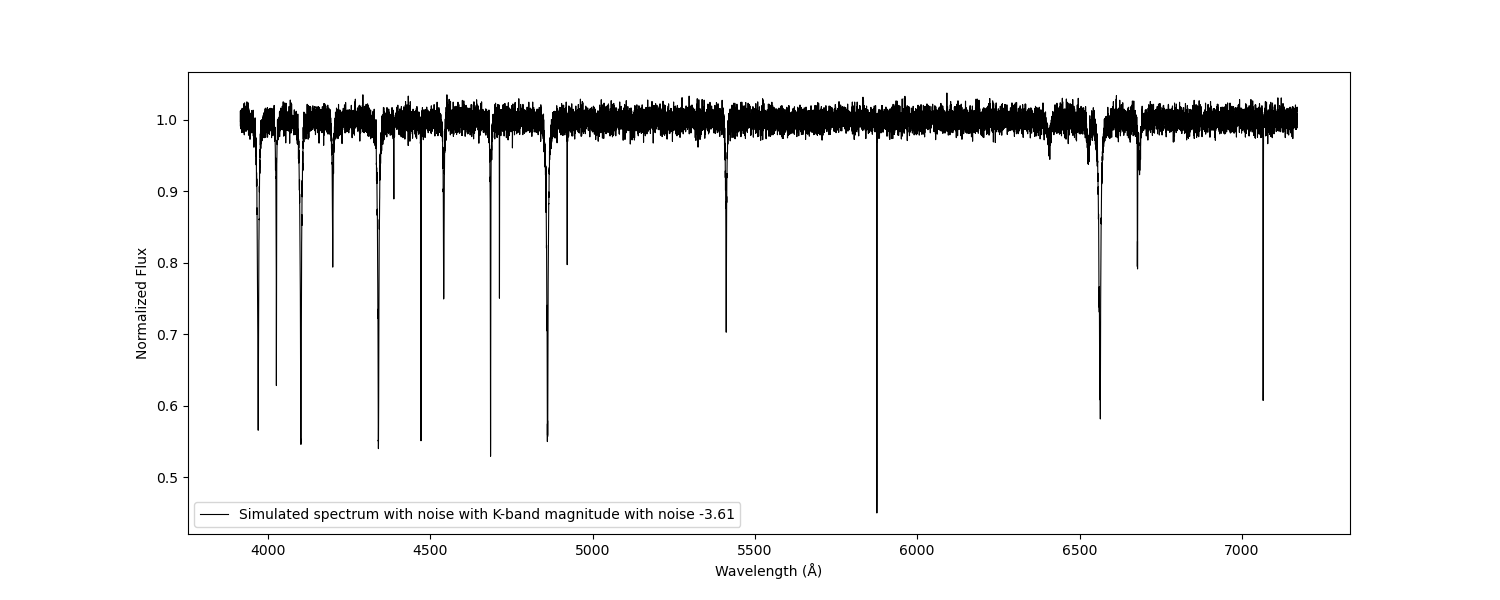

Initial guess: {'teff': 43561.981, 'logg': 3.442, 'radius': 12.179, 'logmdot': -6.607, 'yhe': 0.15}


In [4]:
theta_true=[40000, 4, 8, -7, 0.1]
observed_flux = simulate_model_spectrum(theta_true, model=model) # Simulate a model spectrum
noisy_flux = add_noise_to_spectrum(observed_flux, spectral_snr=100) # Add noise to the simulated spectrum based on the specified SNR
kband_magnitude_with_noise = simulate_kband_magnitude(theta_true) + np.random.normal(0, 1/20) # Simulate the observed K-band magnitude for the true parameters and add noise based on a K-band SNR of 20

plt.figure(figsize=(15, 6))
plt.plot(wl_uniform, noisy_flux, color='black', label=f'Simulated spectrum with noise with K-band magnitude with noise {kband_magnitude_with_noise:.2f}', lw=0.8)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

theta_guess = np.random.uniform(low=[29000, 3.4, 6, -7.5, 0.08], high=[52000, 4.3, 21, -5.2, 0.15]) # Generate a random initial guess within the prior bounds
print('Initial guess:', dict(zip(PARAM_NAMES, np.round(theta_guess, 3))))

In [5]:
results = run_mcmc_with_kband(
    observed_flux=noisy_flux, 
    observed_wavelength=wl_uniform,
    observed_kband=kband_magnitude_with_noise, # Simulate the K-band magnitude for the true parameters to use as the observed K-band magnitude in the MCMC
    spectral_snr=100,
    kband_snr=20,
    first_guess=theta_guess,
    model = model,
    theta_true=theta_true,
    nwalkers=12,
    )

Starting MCMC: 12 walkers × 5000 steps (60,000 total evaluations)
Initial position (MAP estimate): {'teff': 40003.411, 'logg': 4.002, 'radius': 7.814, 'logmdot': -6.988, 'yhe': 0.098}
  Step   500/5000 (10%)  —  mean acceptance: 0.542
  Step  1000/5000 (20%)  —  mean acceptance: 0.546
  Step  1500/5000 (30%)  —  mean acceptance: 0.547
  Step  2000/5000 (40%)  —  mean acceptance: 0.547
  Step  2500/5000 (50%)  —  mean acceptance: 0.547
  Step  3000/5000 (60%)  —  mean acceptance: 0.549
  Step  3500/5000 (70%)  —  mean acceptance: 0.547
  Step  4000/5000 (80%)  —  mean acceptance: 0.548
  Step  4500/5000 (90%)  —  mean acceptance: 0.548
  Step  5000/5000 (100%)  —  mean acceptance: 0.549
Sampling complete.

--- Chain diagnostics ---
  Burn-in discarded : 192 steps (3 × max τ)
  Thinning factor   : 10
  Samples remaining : 5760


true: [40000, 4, 8, -7, 0.1]
MAP: [ 4.00034111e+04  4.00235529e+00  7.81422629e+00 -6.98823226e+00
  9.77045406e-02]
Median and 1σ uncertainties:
teff = 40002.409 -60.618/+60.409, true teff = 40000.000
logg = 4.003 -0.007/+0.007, true logg = 4.000
radius = 7.818 -0.173/+0.168, true radius = 8.000
logmdot = -6.991 -0.039/+0.037, true logmdot = -7.000
yhe = 0.098 -0.001/+0.002, true yhe = 0.100


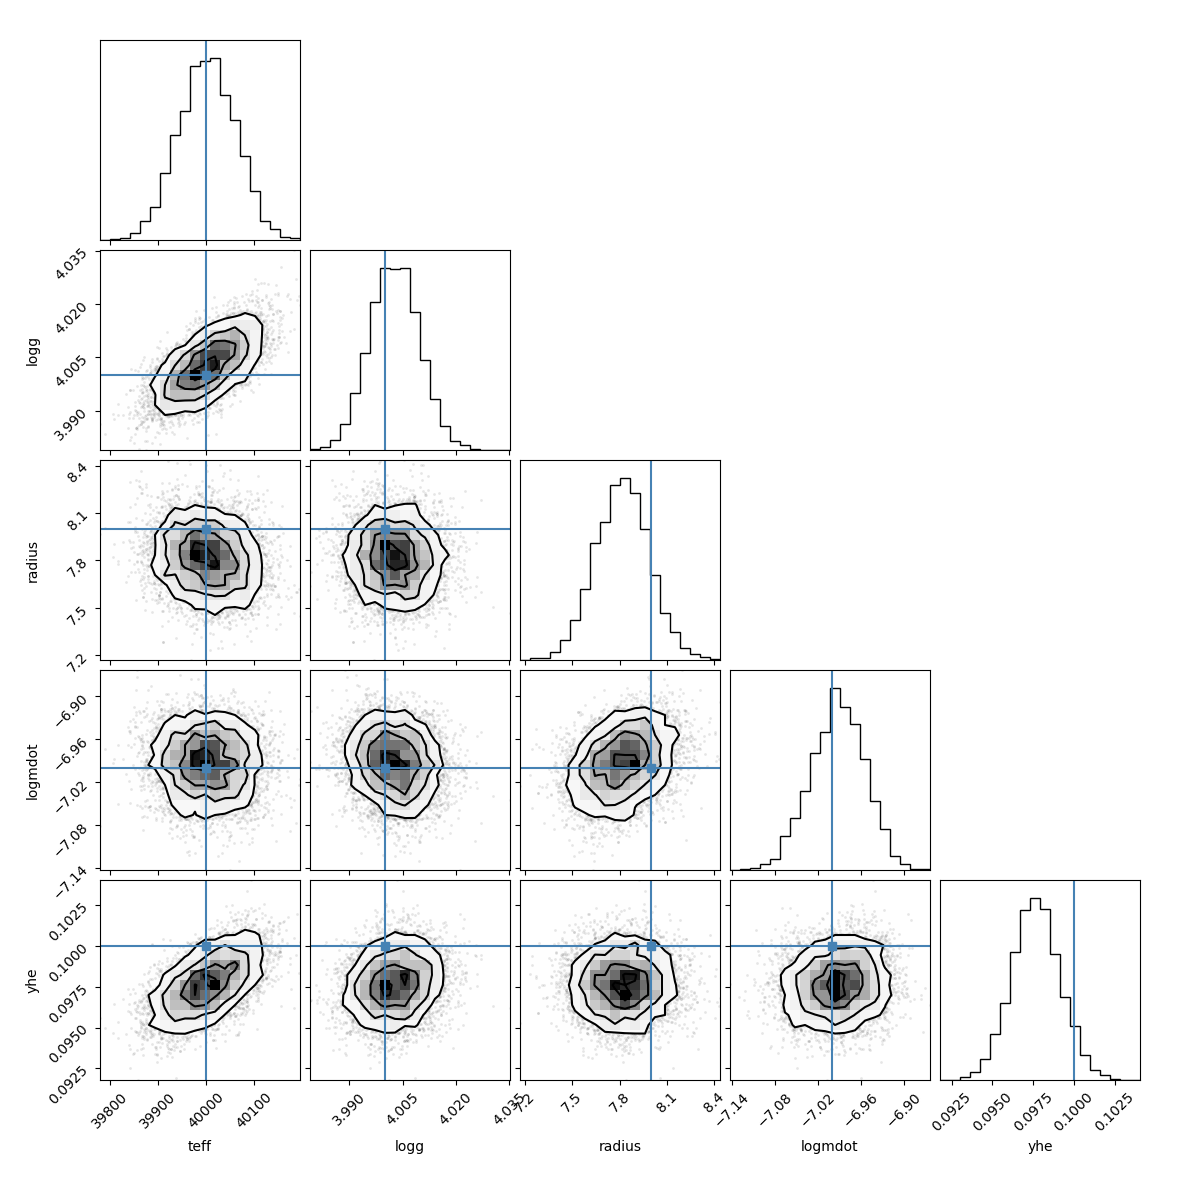

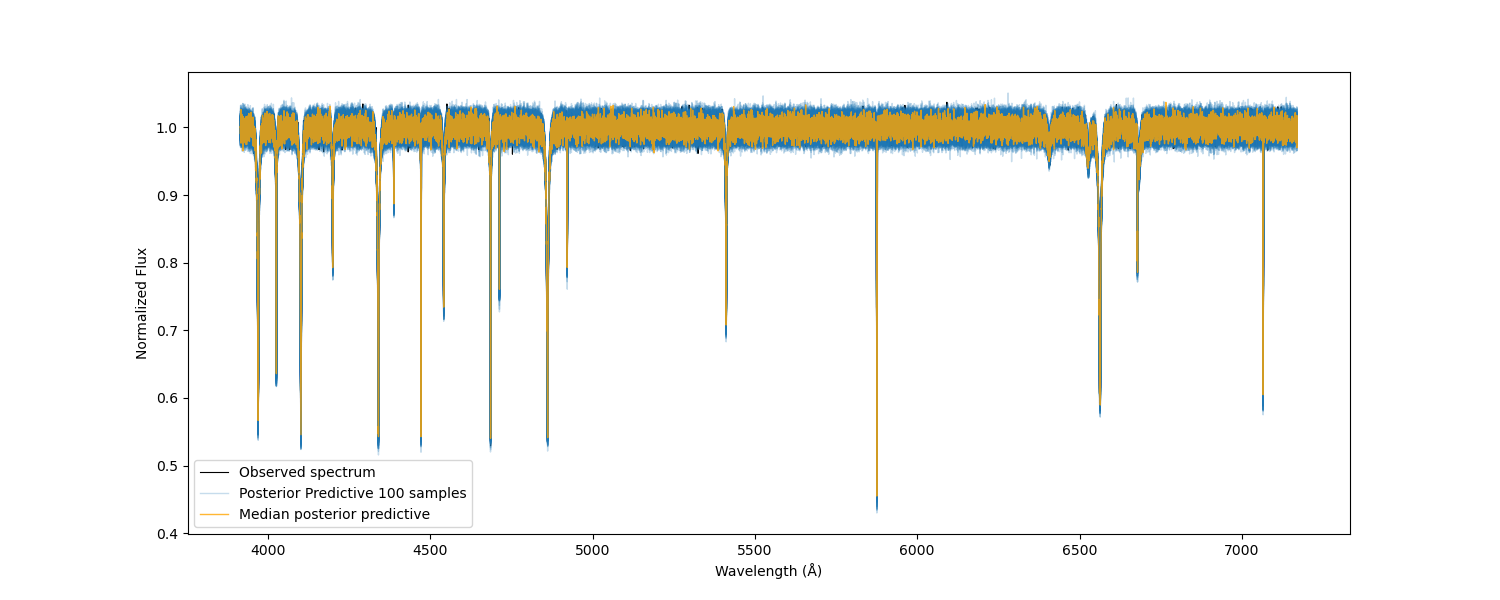

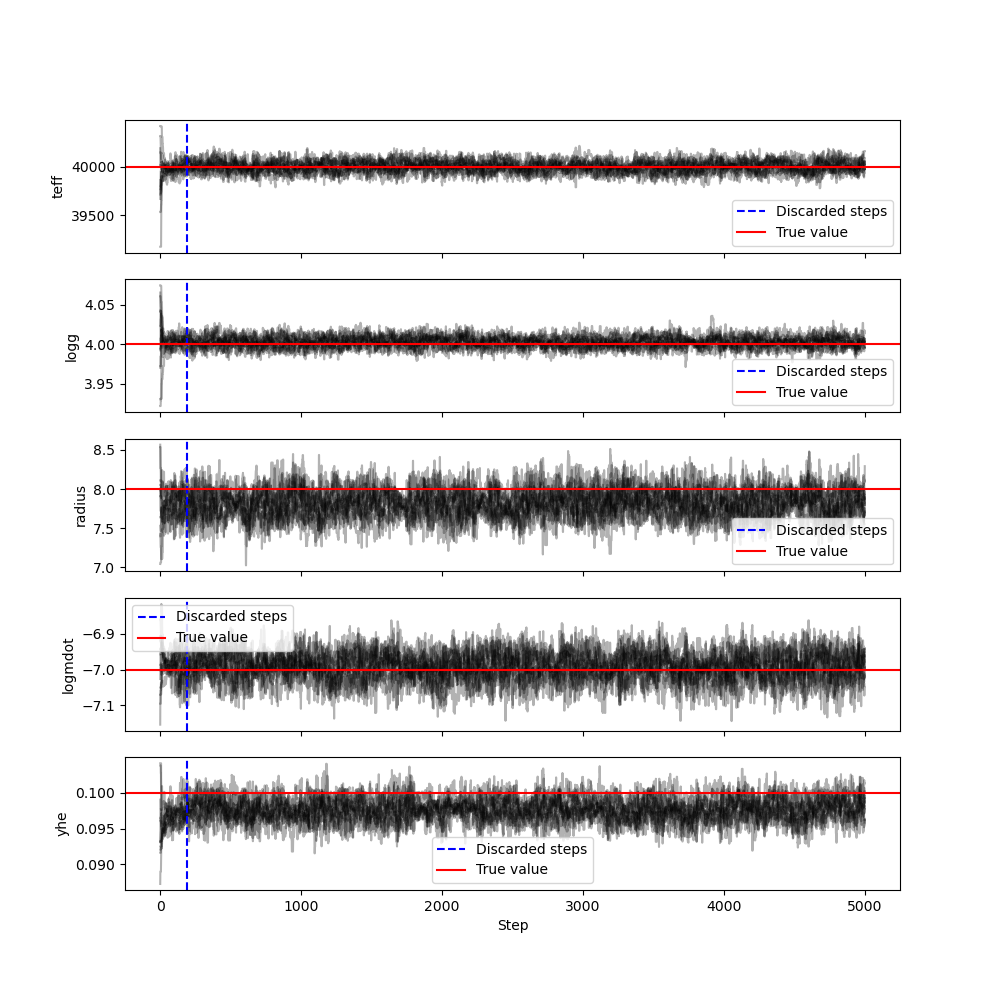

(5760, 5)


In [6]:
print('true:', results["theta_true"])
print('MAP:', results["theta_map"])
print_posterior_summary(results["flat_samples"], truths=results["theta_true"])
plot_corner(results["flat_samples"], results["theta_true"])
plot_posterior_predictive(
    results,
    observed_flux=noisy_flux,
    observed_wavelength=wl_uniform,
    model=model,
    spectral_snr=100,
)
plot_chains(results["chain"], ndim=5, discard=results["discard"], truths=results["theta_true"])
print(results['flat_samples'].shape)

In [7]:
simulate_kband_magnitude(results["theta_50p"])
print('true K-band magnitude:', simulate_kband_magnitude(results["theta_true"]))
print('50th percentile K-band magnitude:', simulate_kband_magnitude(results["theta_50p"]))

true K-band magnitude: -3.685151570455237
50th percentile K-band magnitude: -3.6353177533540264


In [8]:
#credible_dict, theta_true, flat_samples_all, guesses, discard_all, chain_all, results_all = run_coverage_test(model=model,wl_array_output=wl_uniform,spectral_snr=100,kband_snr=20)

Conservative estimators produce curves above the diagonal and overconfident models underneath. Normally you do a 100 simulations 

In [9]:
#plot_coverage_all_params(credible_dict) 

Now try it on the BLOeM grid

In [10]:
theta_true=[40000, 4, 8, -7, 0.1]
flux_on_BLOeM=simulate_model_spectrum(theta_true, model=model, output_wl=bloem_wl) # Simulate the model spectrum for the true parameters on the BLOeM wavelength grid
noisy_flux_on_BLOeM = add_noise_to_spectrum(flux_on_BLOeM, spectral_snr=100) # Add noise to the simulated spectrum based on the specified SNR
kband_magnitude_with_noise = simulate_kband_magnitude(theta_true) + np.random.normal(0, 1/20) # Simulate the observed K-band magnitude for the true parameters

results_on_BLOeM = run_mcmc_with_kband(
    observed_flux=noisy_flux_on_BLOeM, 
    observed_wavelength=bloem_wl,
    observed_kband=kband_magnitude_with_noise,
    spectral_snr=100,
    kband_snr=20,
    first_guess=theta_guess,
    model = model,
    theta_true=theta_true,
    )

Starting MCMC: 24 walkers × 5000 steps (120,000 total evaluations)
Initial position (MAP estimate): {'teff': 40440.316, 'logg': 3.996, 'radius': 9.479, 'logmdot': -7.5, 'yhe': 0.145}
  Step   500/5000 (10%)  —  mean acceptance: 0.529
  Step  1000/5000 (20%)  —  mean acceptance: 0.540
  Step  1500/5000 (30%)  —  mean acceptance: 0.540
  Step  2000/5000 (40%)  —  mean acceptance: 0.542
  Step  2500/5000 (50%)  —  mean acceptance: 0.543
  Step  3000/5000 (60%)  —  mean acceptance: 0.542
  Step  3500/5000 (70%)  —  mean acceptance: 0.543
  Step  4000/5000 (80%)  —  mean acceptance: 0.544
  Step  4500/5000 (90%)  —  mean acceptance: 0.545
  Step  5000/5000 (100%)  —  mean acceptance: 0.545
Sampling complete.

--- Chain diagnostics ---
  Burn-in discarded : 300 steps (3 × max τ)
  Thinning factor   : 10
  Samples remaining : 11280


/var/folders/1c/6z3dmh791ds46smx1bt3qqq00000gn/T/ipykernel_75138/41675627.py:177: RuntimeWarning: Chain may not be converged: nsteps=5000 < 50 × max(tau)=5024. Consider running for at least 5023 steps.
  warnings.warn(


true: [40000, 4, 8, -7, 0.1]
MAP: [ 4.04403164e+04  3.99597734e+00  9.47916735e+00 -7.49999836e+00
  1.45361039e-01]
Median and 1σ uncertainties:
teff = 40044.258 -108.478/+97.477, true teff = 40000.000
logg = 4.008 -0.010/+0.010, true logg = 4.000
radius = 8.140 -0.181/+0.188, true radius = 8.000
logmdot = -6.835 -0.141/+0.119, true logmdot = -7.000
yhe = 0.104 -0.002/+0.002, true yhe = 0.100


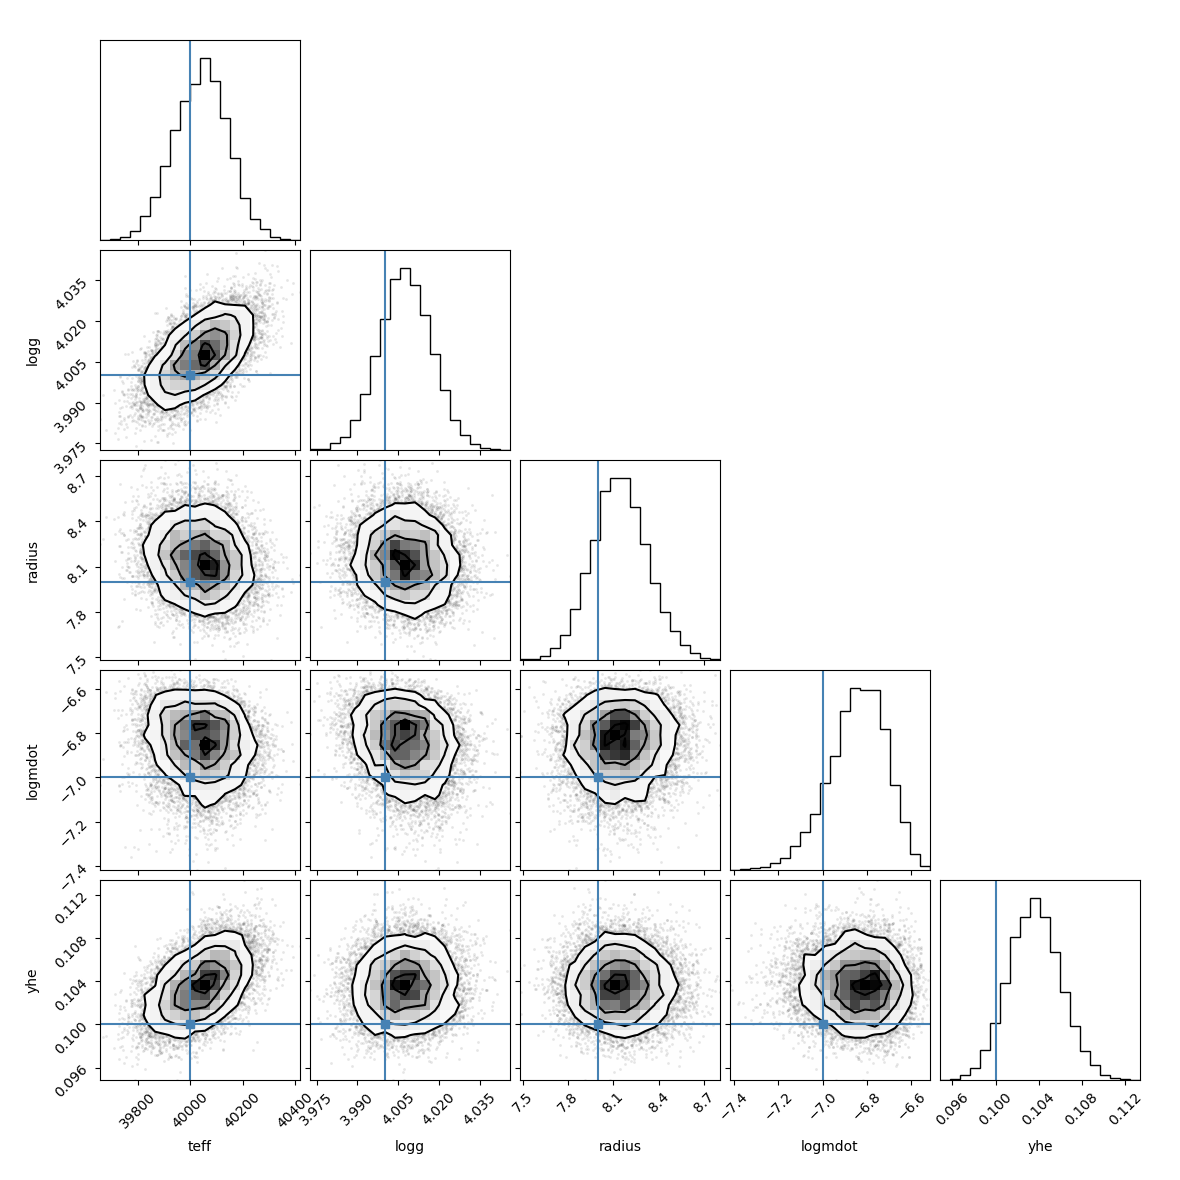

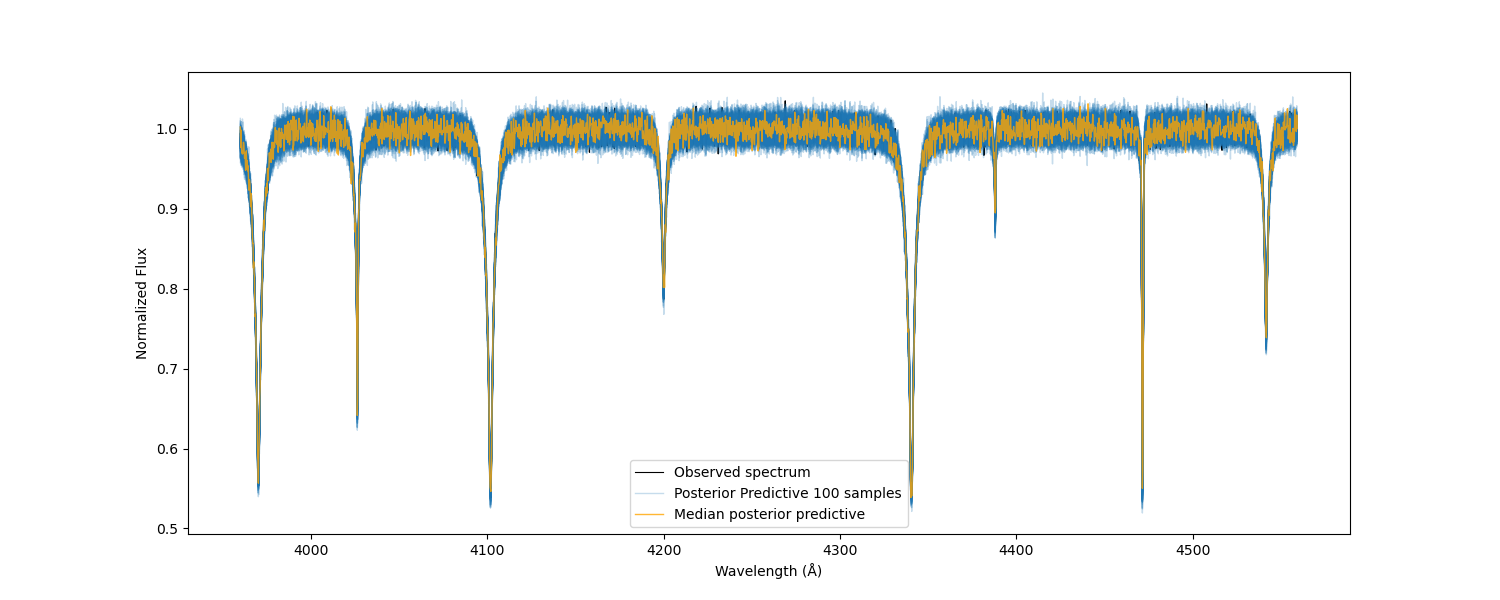

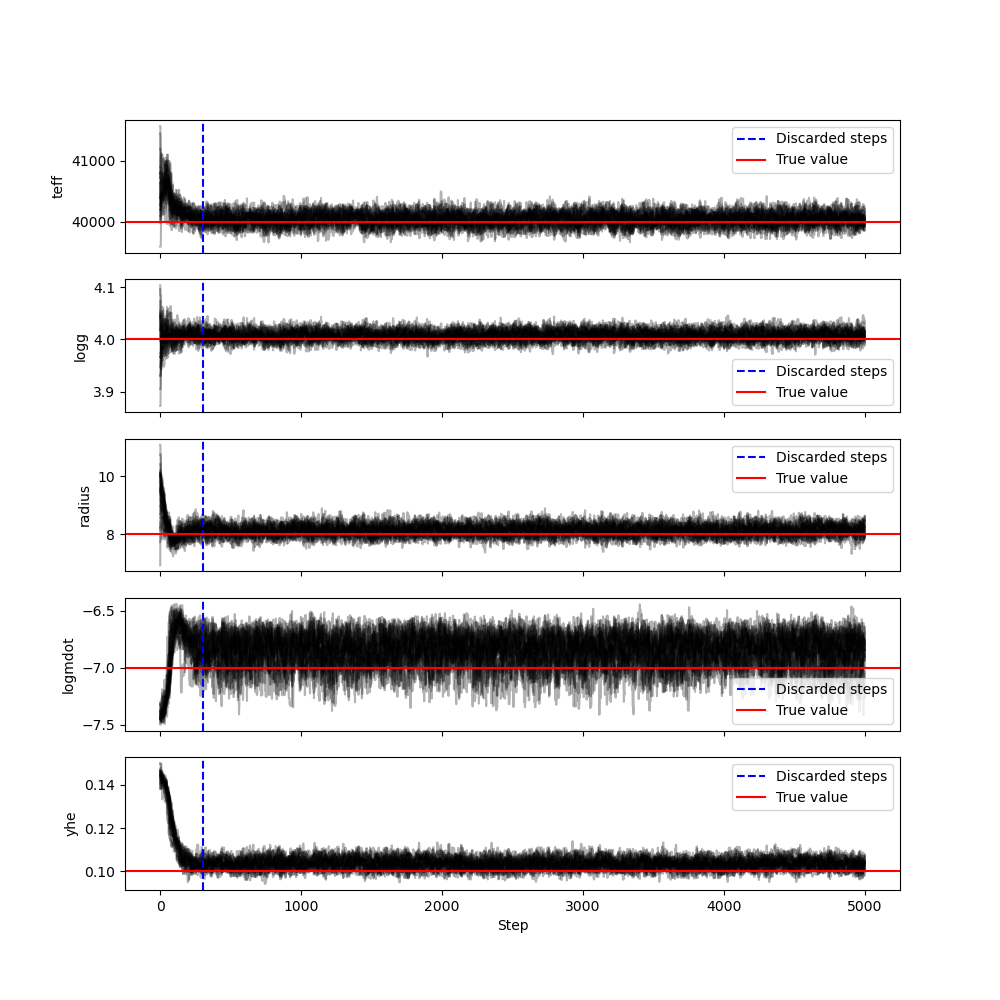

(11280, 5)


In [11]:
print('true:', results_on_BLOeM["theta_true"])
print('MAP:', results_on_BLOeM["theta_map"])
print_posterior_summary(results_on_BLOeM["flat_samples"], truths=results_on_BLOeM["theta_true"])
plot_corner(results_on_BLOeM["flat_samples"], results_on_BLOeM["theta_true"])
plot_posterior_predictive(
    results_on_BLOeM,
    observed_flux=noisy_flux_on_BLOeM,
    observed_wavelength=bloem_wl,
    model=model,
    spectral_snr=100,
)
plot_chains(results_on_BLOeM["chain"], ndim=5, discard=results_on_BLOeM["discard"], truths=results_on_BLOeM["theta_true"])
print(results_on_BLOeM['flat_samples'].shape)

In [12]:
#credible_dict, theta_true, flat_samples_all, guesses, discard_all, chain_all, results_all = run_coverage_test(wl_array_output=bloem_wl,spectral_snr=100,kband_snr=20)

In [13]:
#plot_coverage_all_params(credible_dict)